# Fetal Health Prediction Model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis


from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

In [3]:
df = pd.read_csv('fetal_health.csv')
df.head()



,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [4]:
# remove rows with missing values
print("Number of rows before dropping missing values:", len(df))
df = df.dropna()
print("Number of rows after dropping missing values:", len(df))


Number of rows before dropping missing values: 2126
Number of rows after dropping missing values: 2126


In [5]:
# Check for missing values
print(df.isnull().sum())

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

In [6]:
# check for duplicates
print("Number of duplicate rows:", df.duplicated().sum())
# print('duplicate rows:', df[df.duplicated()])
dupes = df[df.duplicated(keep=False)]
print(dupes["fetal_health"].value_counts())
df = df.drop_duplicates()
print("Number of duplicate rows after dropping duplicates:", df.duplicated().sum())

Number of duplicate rows: 13
fetal_health
1.0    16
2.0     6
3.0     2
Name: count, dtype: int64
Number of duplicate rows after dropping duplicates: 0


In [7]:
target_col = 'fetal_health'

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)
print(X.shape, y.shape)

(2113, 21) (2113,)


In [17]:
cols_to_show = [
    "baseline value",
    "accelerations",
    "prolongued_decelerations",
    "abnormal_short_term_variability",
    "mean_value_of_short_term_variability",
    "histogram_mean",
    "fetal_health"
]

df[cols_to_show].head(6)

,baseline value,accelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,histogram_mean,fetal_health
0,120.0,0.000,0.000,73.0,0.5,137.0,2.0
1,132.0,0.006,0.000,17.0,2.1,136.0,1.0
2,133.0,0.003,0.000,16.0,2.1,135.0,1.0
3,134.0,0.003,0.000,16.0,2.4,134.0,1.0
4,132.0,0.007,0.000,16.0,2.4,136.0,1.0
5,134.0,0.001,0.002,26.0,5.9,107.0,3.0


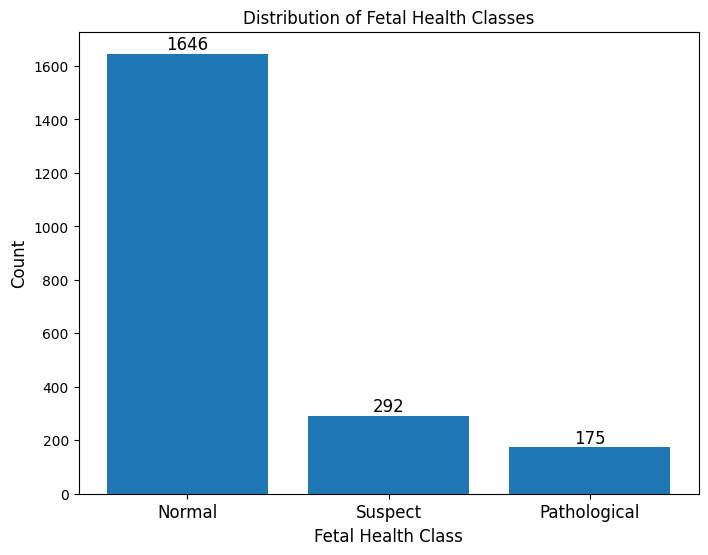

In [8]:
# plot the distribution of the target variable
plt.figure(figsize=(8, 6))
# plt.bar(y.value_counts().index, y.value_counts().values)
# show the count of each class on top of the bars
bars = plt.bar(y.value_counts().index, y.value_counts().values)
plt.bar_label(bars, fontsize=12)
plt.xticks(y.value_counts().index, ['Normal', 'Suspect', 'Pathological'], fontsize=12)
plt.xlabel('Fetal Health Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Fetal Health Classes', fontsize=12)
plt.show()

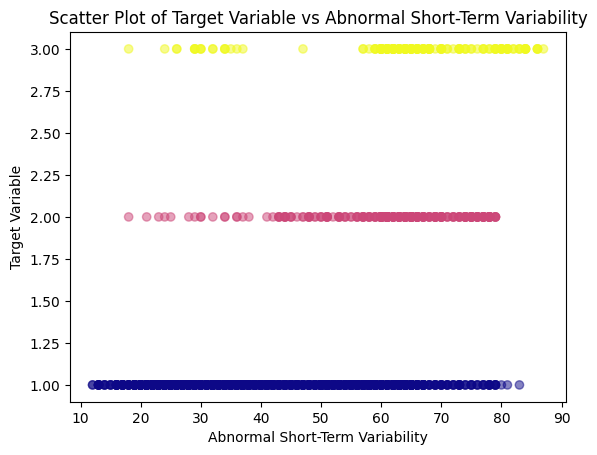

In [8]:
# plotfigure(figsize=(8, 6))
plt.scatter(X['abnormal_short_term_variability'], y, c=y, cmap='plasma', alpha=0.5)
plt.xlabel('Abnormal Short-Term Variability')
plt.ylabel('Target Variable')
plt.title('Scatter Plot of Target Variable vs Abnormal Short-Term Variability')
plt.show() #a scatter plot of the target variable against one of the features


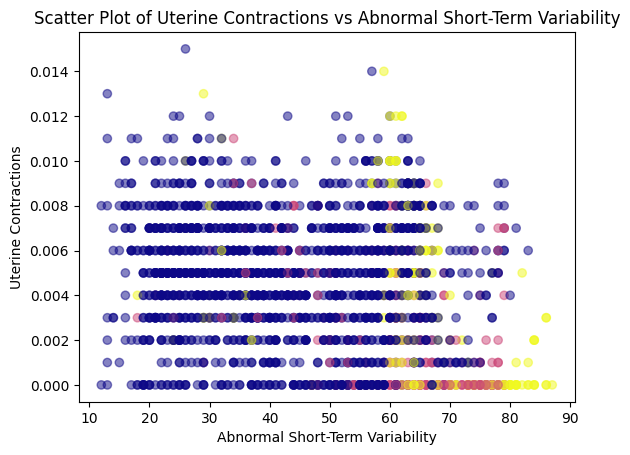

In [10]:
# plotfigure(figsize=(8, 6))
plt.scatter(X['abnormal_short_term_variability'], X['uterine_contractions'], c=y, cmap='plasma', alpha=0.5)
plt.xlabel('Abnormal Short-Term Variability')
plt.ylabel('Uterine Contractions')
plt.title('Scatter Plot of Uterine Contractions vs Abnormal Short-Term Variability')
plt.show() #a scatter plot of the target variable against one of the features


In [9]:
print(len(df))
x = df.drop(columns=['fetal_health'])
y = df['fetal_health'].astype(int)
y = y.replace({1: 0, 2: 1, 3: 2})  # Map classes to 0, 1, 2 for better readability
y.value_counts()

2113


fetal_health
0    1646
1     292
2     175
Name: count, dtype: int64

In [10]:
# print the 5 number summary of the features
print("5 Number Summary of Features:")
print(X.describe())

5 Number Summary of Features:
       baseline value  accelerations  fetal_movement  uterine_contractions  \
count     2113.000000    2113.000000     2113.000000           2113.000000   
mean       133.304780       0.003188        0.009517              0.004387   
std          9.837451       0.003871        0.046804              0.002941   
min        106.000000       0.000000        0.000000              0.000000   
25%        126.000000       0.000000        0.000000              0.002000   
50%        133.000000       0.002000        0.000000              0.005000   
75%        140.000000       0.006000        0.003000              0.007000   
max        160.000000       0.019000        0.481000              0.015000   

       light_decelerations  severe_decelerations  prolongued_decelerations  \
count          2113.000000           2113.000000               2113.000000   
mean              0.001901              0.000003                  0.000159   
std               0.002966       

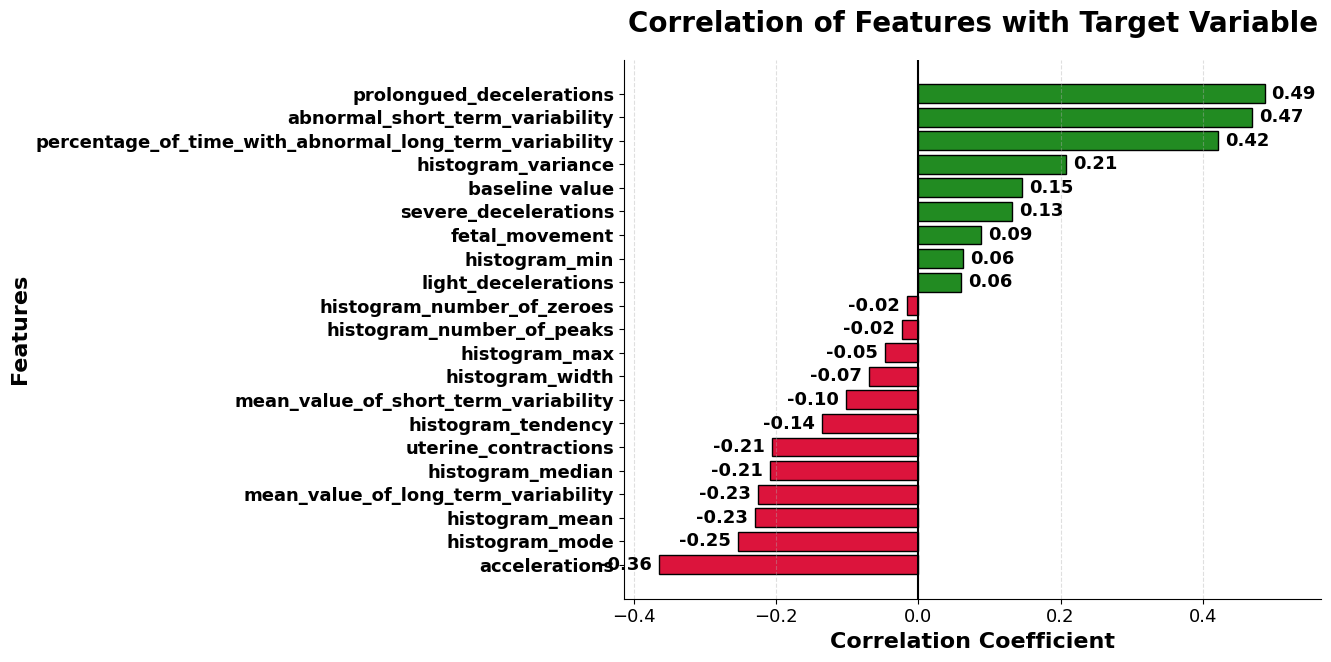

In [11]:

# Compute and sort correlations
correlations = x.corrwith(y).sort_values()

# Create figure
plt.figure(figsize=(9, 7))

# Colors based on sign of correlation
colors = [
    'crimson' if val < 0 else 'forestgreen'
    for val in correlations
]

# Horizontal bars
bars = plt.barh(
    correlations.index,
    correlations.values,
    color=colors,
    edgecolor='black',
    linewidth=1
)

# Vertical line at zero
plt.axvline(0, color='black', linewidth=1.5)

# Add correlation values to each bar
for bar in bars:
    width = bar.get_width()
    y_ = bar.get_y() + bar.get_height() / 2

    if width >= 0:
        plt.text(
            width + 0.01,
            y_,
            f'{width:.2f}',
            va='center',
            ha='left',
            fontsize=13,
            fontweight='bold'
        )
    else:
        plt.text(
            width - 0.01,
            y_,
            f'{width:.2f}',
            va='center',
            ha='right',
            fontsize=13,
            fontweight='bold'
        )

# Formatting
plt.title(
    'Correlation of Features with Target Variable',
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Correlation Coefficient',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel(
    'Features',
    fontsize=16,
    fontweight='bold'
)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.4)

# Remove unnecessary borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Give a little extra room for the value labels
plt.xlim(correlations.min() - 0.05, correlations.max() + 0.08)

# plt.tight_layout()
plt.show()

In [ ]:
# plot a correlation heatmap of the features with each other
plt.figure(figsize=(12, 10))
sns.heatmap(x.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap of Features with Each Other')
plt.show()

/tmp/ipykernel_2112525/765396381.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X[feature][y == 0], X[feature][y == 1], X[feature][y == 2]], labels=['normal', 'suspect', 'pathological'])


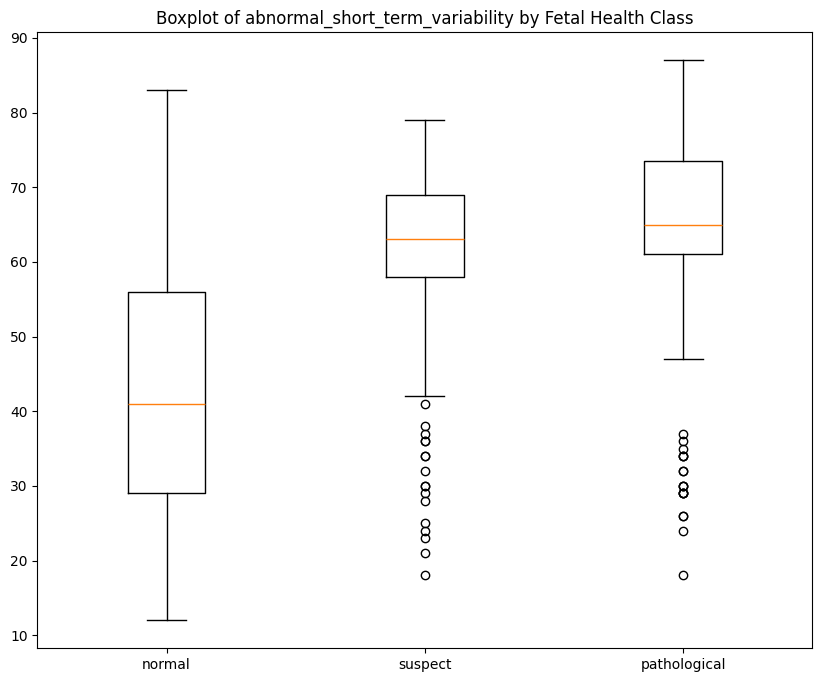

In [12]:
# draw a boxplot of the features with the target variable
feature = 'abnormal_short_term_variability'  # Change this to the feature you want to plot
plt.figure(figsize=(10, 8))
plt.boxplot([X[feature][y == 0], X[feature][y == 1], X[feature][y == 2]], labels=['normal', 'suspect', 'pathological'])
plt.title(f'Boxplot of {feature} by Fetal Health Class')
plt.show()

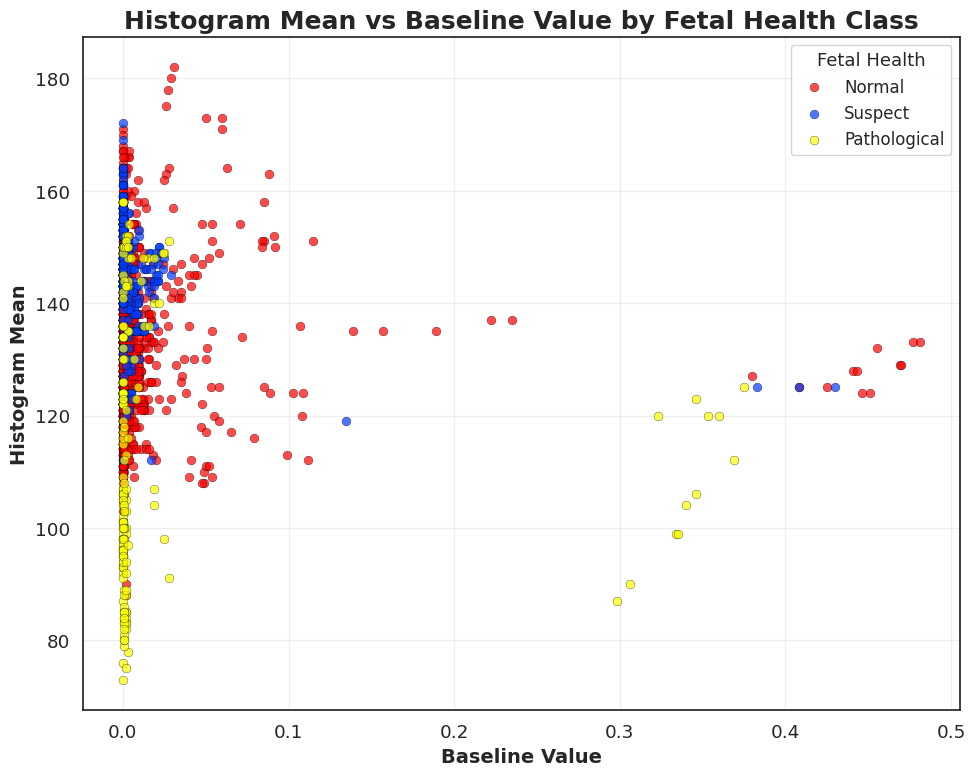

In [69]:
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm

# # Create a discrete colormap with 3 colors
# # 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'crest', 'crest_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'flare', 'flare_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'icefire', 'icefire_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'mako', 'mako_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'rocket', 'rocket_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'vlag', 'vlag_r', 'winter', 'winter_r'

# cmap = cm.get_cmap('cividis', 3)

# fig, ax = plt.subplots(figsize=(10, 8))

# scatter = ax.scatter(
#     X['accelerations'],
#     X['histogram_mean'],
#     c=y,
#     cmap=cmap,
#     alpha=1,
#     edgecolors='k',
#     linewidths=0.3
# )

# # Create legend with custom class names
# handles, _ = scatter.legend_elements()

# class_names = ['Normal', 'Suspect', 'Pathological']

# ax.legend(
#     handles,
#     class_names,
#     title='Fetal Health',
#     loc='upper right',
#     fontsize=12,
#     title_fontsize=13
# )

# ax.set_xlabel('Accelerations', fontsize=13)
# ax.set_ylabel('Histogram Mean', fontsize=13)
# ax.set_title(
#     'Histogram Mean vs Accelerations Colored by Fetal Health Class',
#     fontsize=16,
#     fontweight='bold'
# )

# ax.grid(alpha=1)

# plt.tight_layout()
# plt.show()


import matplotlib.pyplot as plt

# Define colors for each class
colors = {
    0: "#FD0000",   # Blue - Normal
    1: "#003CFF",   # Orange - Suspect
    2: "#FBFF00"    # Red - Pathological
}

labels = {
    0: "Normal",
    1: "Suspect",
    2: "Pathological"
}

plt.figure(figsize=(10, 8))

# Plot each class separately
for cls in [0, 1, 2]:
    mask = y == cls

    plt.scatter(
        X.loc[mask, 'fetal_movement'],
        X.loc[mask, 'histogram_mean'],
        color=colors[cls],
        label=labels[cls],
        alpha=0.7,
        s=40,
        edgecolors='black',
        linewidth=0.3
    )

plt.title(
    "Histogram Mean vs Baseline Value by Fetal Health Class",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Baseline Value",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Histogram Mean",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    title="Fetal Health",
    fontsize=12,
    title_fontsize=13,
    frameon=True
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
# detect outliers using the IQR method for each feature and print the number of outliers detected for each feature
outlier_counts = {}

for feature in X.columns:
    Q1 = X[feature].quantile(0.25)
    Q3 = X[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = X[(X[feature] < lower_bound) | (X[feature] > upper_bound)]
    outlier_counts[feature] = len(outliers)

for feature, count in outlier_counts.items():
    print(f"{feature}: {count} outliers")

baseline value: 0 outliers
accelerations: 14 outliers
fetal_movement: 307 outliers
uterine_contractions: 1 outliers
light_decelerations: 150 outliers
severe_decelerations: 7 outliers
prolongued_decelerations: 178 outliers
abnormal_short_term_variability: 0 outliers
mean_value_of_short_term_variability: 70 outliers
percentage_of_time_with_abnormal_long_term_variability: 309 outliers
mean_value_of_long_term_variability: 71 outliers
histogram_width: 0 outliers
histogram_min: 0 outliers
histogram_max: 24 outliers
histogram_number_of_peaks: 19 outliers
histogram_number_of_zeroes: 502 outliers
histogram_mode: 73 outliers
histogram_mean: 45 outliers
histogram_median: 28 outliers
histogram_variance: 184 outliers
histogram_tendency: 0 outliers


In [13]:
# split data into train and test sets. Strify by target to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (1690, 21) (1690,)
Test set shape: (423, 21) (423,)


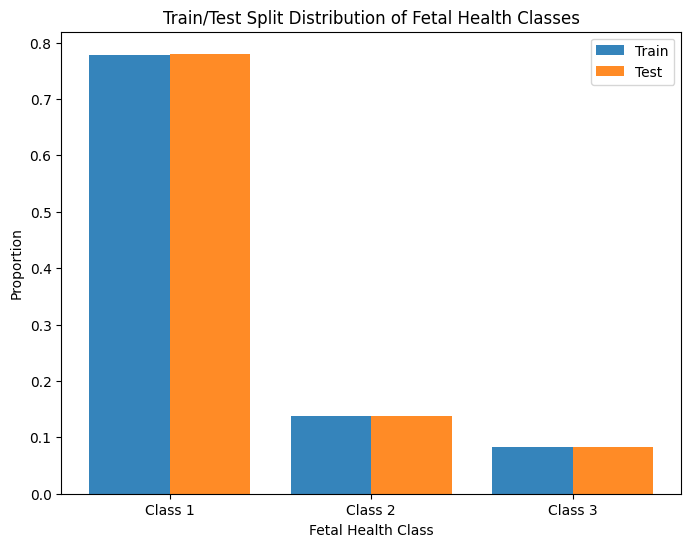

In [14]:
# Train / test split distribution showing the class proportions in the training and testing sets
train_class_distribution = y_train.value_counts(normalize=True)
test_class_distribution = y_test.value_counts(normalize=True)
plt.figure(figsize=(8, 6))
plt.bar(train_class_distribution.index - 0.2, train_class_distribution.values, width=0.4, label='Train', alpha=0.9)
plt.bar(test_class_distribution.index + 0.2, test_class_distribution.values, width=0.4, label='Test', alpha=0.9)
plt.xticks([0, 1, 2], ['Class 1', 'Class 2', 'Class 3'])
plt.xlabel('Fetal Health Class')
plt.ylabel('Proportion')
plt.title('Train/Test Split Distribution of Fetal Health Classes')
plt.legend()
plt.show()
# print("Train Class Distribution:\n", train_class_distribution)
# print("Test Class Distribution:\n", test_class_distribution)

In [15]:
print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

1690 423
1690 423


In [1]:
# Apply SMOTE to the training data to handle class imbalance
# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
# print("Original training set class distribution:")
# print(y_train.value_counts())
# print("Resampled training set class distribution:")
# print(y_train_resampled.value_counts())

In [18]:
# selector = SelectKBest(
#     score_func=f_classif,
#     k=10
# )
# X_train_selected = selector.fit_transform(
#     X_train_resampled, y_train_resampled
# )

# X_test_selected = selector.transform(X_test)
# selected_features = X_train_resampled.columns[
#     selector.get_support()
# ]

# print(selected_features, len(selected_features))

In [16]:
knn_for_selection = KNeighborsClassifier(n_neighbors=5)

# ── Pipeline ─────────────────────────────────────────────────────────────────
model = Pipeline([
    ("scaler",   StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("selector", SequentialFeatureSelector(
                     knn_for_selection,
                     n_features_to_select=10,   # starting point; can also grid search this
                     direction="forward",
                     scoring="f1_macro",
                     cv=3                        # inner CV for SFS (keep low for speed)
                 )),
    ("model",    KNeighborsClassifier())         # this one gets tuned
])

# ── Parameter grid ────────────────────────────────────────────────────────────
# Format: "step_name__parameter_name"
param_grid = {
    "selector__n_features_to_select": [5, 10, 15, 20],  # try different subset sizes
    "model__n_neighbors":             [3, 5, 7, 11, 15],
    "model__weights":                 ["uniform", "distance"],
    "model__metric":                  ["euclidean", "manhattan"]
}

# ── Cross-validation strategy ─────────────────────────────────────────────────
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Grid search ───────────────────────────────────────────────────────────────
grid_search_knn = GridSearchCV(
    estimator=model,
    param_grid=param_grid, 
    cv=cv_outer,
    scoring="f1_macro",
    n_jobs=-1,          # use all CPU cores
    # verbose=2,          # print progress
    error_score="raise" # surface errors immediately
)

grid_search_knn.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Best CV F1:  {grid_search_knn.best_score_:.4f}")
print(f"Best Params: {grid_search_knn.best_params_}")

# ── mean and std of CV F1 across folds ───────────────────────────────────
cv_scores_knn = cross_val_score(
    grid_search_knn.best_estimator_,
    X_train, y_train,
    cv=cv_outer,
    scoring="f1_macro"
)

print(f"\nCV F1 per fold:  {np.round(cv_scores_knn, 4)}")
print(f"CV F1 mean:      {cv_scores_knn.mean():.4f}")
print(f"CV F1 std:       {cv_scores_knn.std():.4f}")
print(f"=> {cv_scores_knn.mean():.4f} ± {cv_scores_knn.std():.4f}")

# ── Evaluate on held-out test set ─────────────────────────────────────────────
y_pred_knn = grid_search_knn.predict(X_test)
print(f"Test F1:     {f1_score(y_test, y_pred_knn, average='macro'):.4f}")

# ── Inspect selected features from best model ─────────────────────────────────
best_pipeline  = grid_search_knn.best_estimator_
best_selector  = best_pipeline.named_steps["selector"]
selected_mask  = best_selector.get_support()
selected_features = X.columns[selected_mask]
print(f"\nSelected features ({selected_mask.sum()}):")
print(selected_features.tolist())

# ── Full results as DataFrame (useful for analysis) ───────────────────────────
results_df = pd.DataFrame(grid_search_knn.cv_results_)
results_df = results_df[[
    "param_selector__n_features_to_select",
    "param_model__n_neighbors",
    "param_model__weights",
    "param_model__metric",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

print(results_df.head(10))

Best CV F1:  0.8588
Best Params: {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'uniform', 'selector__n_features_to_select': 10}

CV F1 per fold:  [0.8464 0.8464 0.8363 0.9034 0.8616]
CV F1 mean:      0.8588
CV F1 std:       0.0237
=> 0.8588 ± 0.0237
Test F1:     0.8676

Selected features (10):
['baseline value', 'accelerations', 'fetal_movement', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'histogram_mean', 'histogram_median']
    param_selector__n_features_to_select  param_model__n_neighbors  \
41                                    10                         3   
45                                    10                         3   
46                                    15                         3   
54                                    15                         5   
42                                    15          

In [17]:
# ── fixed LogReg inside SFS (no tuning inside selector) ──────────────────

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

logreg_for_selection = LogisticRegression(
    solver="saga",
    random_state=42
)

# ── pipeline ──────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ("scaler",   StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("selector", SequentialFeatureSelector(
                        logreg_for_selection,
                        n_features_to_select=10,   # starting point for grid search
                        direction="forward",
                        scoring="f1_macro",
                        cv=3                        # inner CV — kept low for speed
                    )),
    ("model",    LogisticRegression(solver="saga", random_state=42))
])

# ── parameter grid ────────────────────────────────────────────────────────
param_grid = [
      {
            "selector__n_features_to_select": [5, 10, 15, 20],
            "model__C":            [0.01, 0.1, 1, 10, 100],
            "model__l1_ratio":     [0, 1],   # 0 = l2,  1 = l1
            # "model__class_weight": [None, "balanced"],
            "model__max_iter": [1000, 2000, 3000, 5000]
        },
        # no penalty — C=np.inf disables regularization
        {
            "selector__n_features_to_select": [5, 10, 15, 20],
            "model__C":            [np.inf],
            # "model__class_weight": [None, "balanced"],
            "model__max_iter": [1000, 2000, 3000, 5000]
        }
]

# ── outer cross-validation ────────────────────────────────────────────────
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── grid search ───────────────────────────────────────────────────────────
grid_search_logreg = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_outer,
    scoring="f1_macro",
    n_jobs=-1,
    # verbose=2,
    # error_score="raise"
)

grid_search_logreg.fit(X_train, y_train)

# ── best params + CV score ────────────────────────────────────────────────
print("=" * 60)
print("LOGISTIC REGRESSION — RESULTS")
print("=" * 60)
print(f"Best Params:  {grid_search_logreg.best_params_}")
print(f"Best CV F1:   {grid_search_logreg.best_score_:.4f}")

# ── mean and std of CV F1 across folds ───────────────────────────────────
cv_scores_logreg = cross_val_score(
    grid_search_logreg.best_estimator_,
    X_train, y_train,
    cv=cv_outer,
    scoring="f1_macro"
)

print(f"\nCV F1 per fold:  {np.round(cv_scores_logreg, 4)}")
print(f"CV F1 mean:      {cv_scores_logreg.mean():.4f}")
print(f"CV F1 std:       {cv_scores_logreg.std():.4f}")
print(f"=> {cv_scores_logreg.mean():.4f} ± {cv_scores_logreg.std():.4f}")

# ── test set evaluation ───────────────────────────────────────────────────
y_pred_logreg = grid_search_logreg.predict(X_test)

print(f"\nTest F1:         {f1_score(y_test, y_pred_logreg, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_logreg,
    target_names=["Normal", "Suspect", "Pathological"]
))

# ── selected features ─────────────────────────────────────────────────────
best_selector     = grid_search_logreg.best_estimator_.named_steps["selector"]
selected_features = X_train.columns[best_selector.get_support()]

print(f"Selected features ({len(selected_features)}):")
print(selected_features.tolist())


LOGISTIC REGRESSION — RESULTS
Best Params:  {'model__C': 10, 'model__l1_ratio': 0, 'model__max_iter': 1000, 'selector__n_features_to_select': 20}
Best CV F1:   0.7901

CV F1 per fold:  [0.7503 0.7792 0.7925 0.8295 0.799 ]
CV F1 mean:      0.7901
CV F1 std:       0.0259
=> 0.7901 ± 0.0259

Test F1:         0.7804

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.90      0.93       330
     Suspect       0.57      0.76      0.65        58
Pathological       0.72      0.80      0.76        35

    accuracy                           0.87       423
   macro avg       0.75      0.82      0.78       423
weighted avg       0.89      0.87      0.88       423

Selected features (20):
['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abno

In [23]:
from sklearn.svm import SVC


# ── Fixed SVC inside SFS (cheap, no tuning) ───────────────────────────────────
svc_for_selection = SVC(kernel="rbf", C=1.0, gamma="scale")

# ── Pipeline ──────────────────────────────────────────────────────────────────
model = Pipeline([
    ("scaler",   StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("selector", SequentialFeatureSelector(
                     svc_for_selection,
                     n_features_to_select=10,
                     direction="forward",
                     scoring="f1_macro",
                     cv=3
                 )),
    ("model",    SVC(probability=True))   # this one gets tuned
])

# ── Parameter grid ────────────────────────────────────────────────────────────
param_grid = [
    # RBF kernel — most powerful, tune C and gamma
    {
        "selector__n_features_to_select": [20],
        "model__kernel": ["rbf"],
        "model__C":      [100],
        "model__gamma":  [0.1],
        # "model__class_weight": [None, "balanced"]
    },
    # Linear kernel — good baseline, only tune C
    {
        "selector__n_features_to_select": [5, 10, 15, 20],
        "model__kernel": ["linear"],
        "model__C":      [0.1, 1, 10, 100],
        # "model__class_weight": [None, "balanced"]
    }
]

# ── Grid search ───────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_svc = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    # verbose=2,
    error_score="raise"
)

grid_search_svc.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Best CV F1:  {grid_search_svc.best_score_:.4f}")
print(f"Best Params: {grid_search_svc.best_params_}")

# ── mean and std of CV F1 across folds ───────────────────────────────────
cv_scores_svc = cross_val_score(
    grid_search_svc.best_estimator_,
    X_train, y_train,
    cv=cv,
    scoring="f1_macro"
)

print(f"\nCV F1 per fold:  {np.round(cv_scores_svc, 4)}")
print(f"CV F1 mean:      {cv_scores_svc.mean():.4f}")
print(f"CV F1 std:       {cv_scores_svc.std():.4f}")
print(f"=> {cv_scores_svc.mean():.4f} ± {cv_scores_svc.std():.4f}")

y_pred_svc = grid_search_svc.predict(X_test)
print(f"Test F1:     {f1_score(y_test, y_pred_svc, average='macro'):.4f}")

# ── Selected features ─────────────────────────────────────────────────────────
best_selector = grid_search_svc.best_estimator_.named_steps["selector"]
selected_features = X.columns[best_selector.get_support()]
print(f"\nSelected features: {selected_features.tolist()}")

Best CV F1:  0.8431
Best Params: {'model__C': 100, 'model__gamma': 0.1, 'model__kernel': 'rbf', 'selector__n_features_to_select': 20}

CV F1 per fold:  [0.8153 0.8508 0.8038 0.8818 0.8638]
CV F1 mean:      0.8431
CV F1 std:       0.0293
=> 0.8431 ± 0.0293
Test F1:     0.8830

Selected features: ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_width', 'histogram_min', 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean', 'histogram_median', 'histogram_variance']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


# ── Cross-validation strategies ───────────────────────────────────────────────
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # inside RFECV
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # inside GridSearchCV

# ── Pipeline (no scaler needed for RFC) ───────────────────────────────────────
model = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("selector", RFECV(
                     estimator=RandomForestClassifier(
                         n_estimators=100,   # fixed inside selector for speed
                         random_state=42
                     ),
                     step=1,                 # remove 1 feature per step
                     cv=cv_inner,
                     scoring="f1_macro",
                     min_features_to_select=5,  # floor — never go below this
                     n_jobs=-1
                 )),
    ("model",    RandomForestClassifier(random_state=42))   # this one gets tuned
])

# ── Parameter grid ────────────────────────────────────────────────────────────
param_grid = {
    # RFECV params
    "selector__min_features_to_select": [5, 10, 15],  # tune the floor
    "selector__step":                   [1, 2, 3],    # features removed per step

    # RFC params (the final model)
    "model__n_estimators":              [100, 200, 300],
    "model__max_depth":                 [None, 5, 10, 20],
    "model__min_samples_split":         [2, 5, 10],
    "model__max_features":              ["sqrt", "log2"]
    # "model__class_weight":              ["balanced", None]
}

# ── Grid search ───────────────────────────────────────────────────────────────
grid_search_rfc = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv_outer,
    scoring="f1_macro",
    n_jobs=-1,
    # verbose=2,
    error_score="raise"
)

grid_search_rfc.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Best CV F1:  {grid_search_rfc.best_score_:.4f}")
print(f"Best Params: {grid_search_rfc.best_params_}")


# ── mean and std of CV F1 across folds ───────────────────────────────────
cv_scores_rfc = cross_val_score(
    grid_search_rfc.best_estimator_,
    X_train, y_train,
    cv=cv_outer,
    scoring="f1_macro"
)

print(f"\nCV F1 per fold:  {np.round(cv_scores_rfc, 4)}")
print(f"CV F1 mean:      {cv_scores_rfc.mean():.4f}")
print(f"CV F1 std:       {cv_scores_rfc.std():.4f}")
print(f"=> {cv_scores_rfc.mean():.4f} ± {cv_scores_rfc.std():.4f}")


y_pred_rfc = grid_search_rfc.predict(X_test)
print(f"\nTest F1: {f1_score(y_test, y_pred_rfc, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rfc))

# ── Inspect selected features ─────────────────────────────────────────────────
best_pipeline = grid_search_rfc.best_estimator_
best_selector = best_pipeline.named_steps["selector"]

selected_mask     = best_selector.get_support()
selected_features = X.columns[selected_mask]
n_selected        = selected_mask.sum()

print(f"\nRFECV selected {n_selected} features (from {X.shape[1]} total):")
print(selected_features.tolist())

# ── Feature importances from final RFC ────────────────────────────────────────
best_rfc = best_pipeline.named_steps["model"]
importance_df = pd.DataFrame({
    "feature":    selected_features,
    "importance": best_rfc.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature Importances (final model):")
print(importance_df.to_string(index=False))

# ── How many features RFECV chose at each CV fold ─────────────────────────────
print(f"\nRFECV optimal feature count: {best_selector.n_features_}")
print(f"RFECV CV scores across feature counts:\n{best_selector.cv_results_}")

# ── Full grid search results ──────────────────────────────────────────────────
results_df = pd.DataFrame(grid_search_rfc.cv_results_)
results_df = results_df[[
    "param_selector__min_features_to_select",
    "param_selector__step",
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__max_features",
    # "param_model__class_weight",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

print("\nTop 10 parameter combinations:")
print(results_df.head(10).to_string(index=False))

/home/dll0706/Documents/Bakwowi_Junior_CV_Project/.conda_venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/dll0706/Documents/Bakwowi_Junior_CV_Project/.conda_venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/dll0706/Documents/Bakwowi_Junior_CV_Project/.conda_venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thr

Best CV F1:  0.8963
Best Params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 100, 'selector__min_features_to_select': 5, 'selector__step': 3}

CV F1 per fold:  [0.8851 0.9002 0.8663 0.9269 0.903 ]
CV F1 mean:      0.8963
CV F1 std:       0.0201
=> 0.8963 ± 0.0201

Test F1: 0.8867

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       330
           1       0.84      0.71      0.77        58
           2       0.92      0.94      0.93        35

    accuracy                           0.94       423
   macro avg       0.90      0.88      0.89       423
weighted avg       0.93      0.94      0.93       423


RFECV selected 18 features (from 21 total):
['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability

KeyError: "['param_model__class_weight'] not in index"

In [ ]:
# plot the stratified distribution of the target variable in the train and test sets
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# sns.countplot(x=y_train.columns[0], data=y_train, ax=axes[0])
# axes[0].set_title('Train Set Distribution')
# sns.countplot(x=y_test.columns[0], data=y_test, ax=axes[1])
# axes[1].set_title('Test Set Distribution')
# plt.show(),,,,,

/tmp/ipykernel_2112525/1189347552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


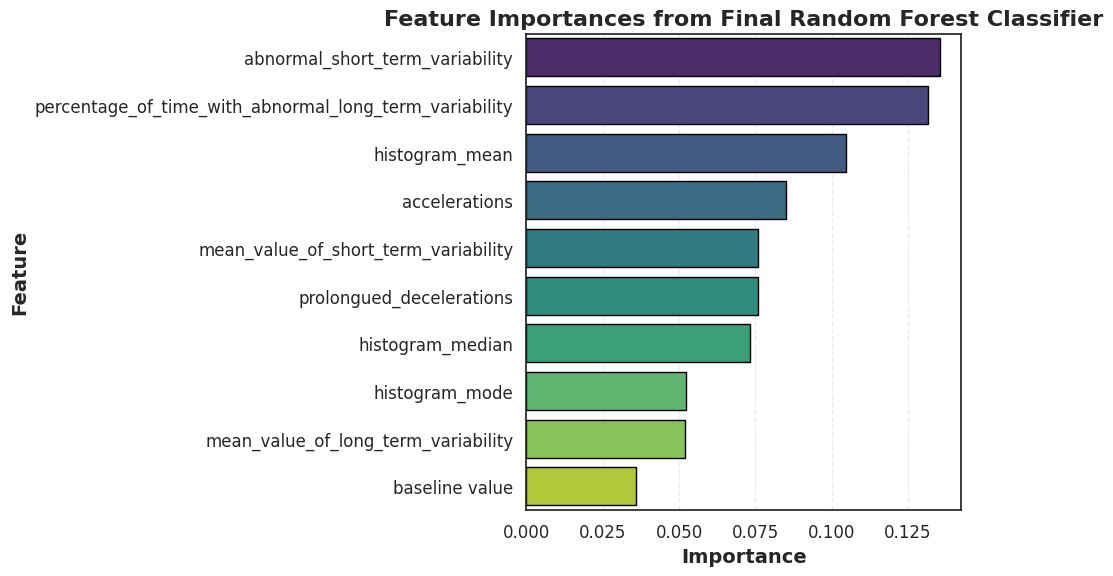

In [32]:
# plot feature importances from the final RFC model
plt.figure(figsize=(10, 6))
sns.barplot(
    x="importance",
    y="feature",
    data=importance_df[:10],  # top 10 features
    orient="h",
    edgecolor="black",
    palette="viridis"
)
plt.title('Feature Importances from Final Random Forest Classifier', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=14, fontweight='bold')
plt.ylabel('Feature', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Accuracy : 0.9362
Macro Precision : 0.902
Macro Recall : 0.8752
Macro F1 : 0.8867
Weighted F1 : 0.9341

Classification Report:

              precision    recall  f1-score   support

      Normal       0.95      0.98      0.96       330
     Suspect       0.84      0.71      0.77        58
Pathological       0.92      0.94      0.93        35

    accuracy                           0.94       423
   macro avg       0.90      0.88      0.89       423
weighted avg       0.93      0.94      0.93       423



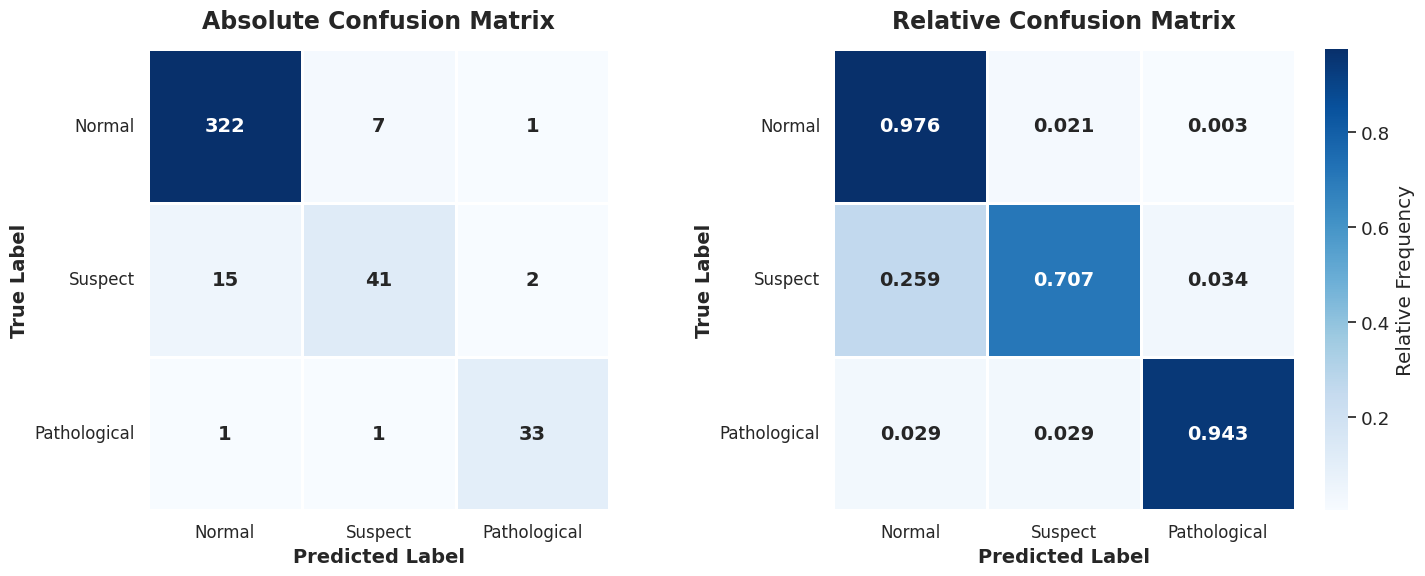

In [37]:

# # fit the pipeline on the training data
# y_pred_rfc = model.fit(X_train_resampled, y_train_resampled).predict(X_test)

# # Access the selector step from the pipeline
# sfs_step = model.named_steps["selector"]

# # Now .get_support() works as normal
# selected_mask = sfs_step.get_support()
# selected_features = X.columns[selected_mask]
# print("Selected features:", selected_features.tolist())

# ─────────────────────────────────────────────
# Best Results
# ─────────────────────────────────────────────



# print("Best Parameters:")
# print(model.best_params_)

# print("\nBest CV Macro F1:")
# print(model.best_score_)



accuracy = accuracy_score(y_test, y_pred_rfc)

precision_macro = precision_score(
    y_test, y_pred_rfc,
    average='macro'
)

recall_macro = recall_score(
    y_test, y_pred_rfc,
    average='macro'
)

f1_macro = f1_score(
    y_test, y_pred_rfc,
    average='macro'
)

f1_weighted = f1_score(
    y_test, y_pred_rfc,
    average='weighted'
)


print("Accuracy :", round(accuracy, 4))
print("Macro Precision :", round(precision_macro, 4))
print("Macro Recall :", round(recall_macro, 4))
print("Macro F1 :", round(f1_macro, 4))
print("Weighted F1 :", round(f1_weighted, 4))


print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_rfc,
    target_names=[
        "Normal",
        "Suspect",
        "Pathological"
    ]
))


cm = confusion_matrix(y_test, y_pred_rfc, normalize='true')

# # Plot absolute and relative confusion matrix

# plt.figure(figsize=(7,6))

# sns.heatmap(
#     cm,
#     annot=True,
#     fmt='d',
#     cmap='Blues',
#     xticklabels=[
#         "Normal",
#         "Suspect",
#         "Pathological"
#     ],
#     yticklabels=[
#         "Normal",
#         "Suspect",
#         "Pathological"
#     ]
# )



# class_names = ['Normal', 'Suspect', 'Pathological']

# # Plot
# plt.figure(figsize=(8, 6))

# sns.set_theme(font_scale=1.3)

# ax = sns.heatmap(
#     cm,
#     annot=True,
#     fmt=".3f",              # Display floating-point values
#     cmap="Blues",
#     square=True,
#     linewidths=1,
#     linecolor="white",
#     # cbar_kws={"label": "Relative Frequency"},
#     xticklabels=class_names,
#     yticklabels=class_names,
#     annot_kws={"size": 14, "weight": "bold"}
# )

# plt.title(
#     "Relative Confusion Matrix",
#     fontsize=18,
#     fontweight="bold",
#     pad=15
# )

# plt.xlabel(
#     "Predicted Label",
#     fontsize=15,
#     fontweight="bold"
# )

# plt.ylabel(
#     "True Label",
#     fontsize=15,
#     fontweight="bold"
# )

# plt.xticks(fontsize=13)
# plt.yticks(fontsize=13, rotation=0)

# plt.tight_layout()
# plt.show()


# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")
# plt.show()







# Compute confusion matrices
cm_abs = confusion_matrix(y_test, y_pred_rfc, normalize=None)
cm_rel = confusion_matrix(y_test, y_pred_rfc, normalize='true')

# Class names
class_names = ['Normal', 'Suspect', 'Pathological']
# Or automatically:
# class_names = np.unique(y_test)

sns.set_theme(style="white", font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -------------------------
# Absolute Confusion Matrix
# -------------------------
sns.heatmap(
    cm_abs,
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    linewidths=1,
    linecolor='white',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"},
    ax=axes[0]
)

axes[0].set_title(
    "Absolute Confusion Matrix",
    fontsize=17,
    fontweight='bold',
    pad=15
)
axes[0].set_xlabel("Predicted Label", fontsize=14, fontweight='bold')
axes[0].set_ylabel("True Label", fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0, labelsize=12)
axes[0].tick_params(axis='y', rotation=0, labelsize=12)

# -------------------------
# Relative Confusion Matrix
# -------------------------
sns.heatmap(
    cm_rel,
    annot=True,
    fmt=".3f",
    cmap='Blues',
    square=True,
    linewidths=1,
    linecolor='white',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    cbar_kws={"label": "Relative Frequency"},
    annot_kws={"size": 14, "weight": "bold"},
    ax=axes[1]
)

axes[1].set_title(
    "Relative Confusion Matrix",
    fontsize=17,
    fontweight='bold',
    pad=15
)
axes[1].set_xlabel("Predicted Label", fontsize=14, fontweight='bold')
axes[1].set_ylabel("True Label", fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0, labelsize=12)
axes[1].tick_params(axis='y', rotation=0, labelsize=12)

plt.tight_layout()
plt.show()

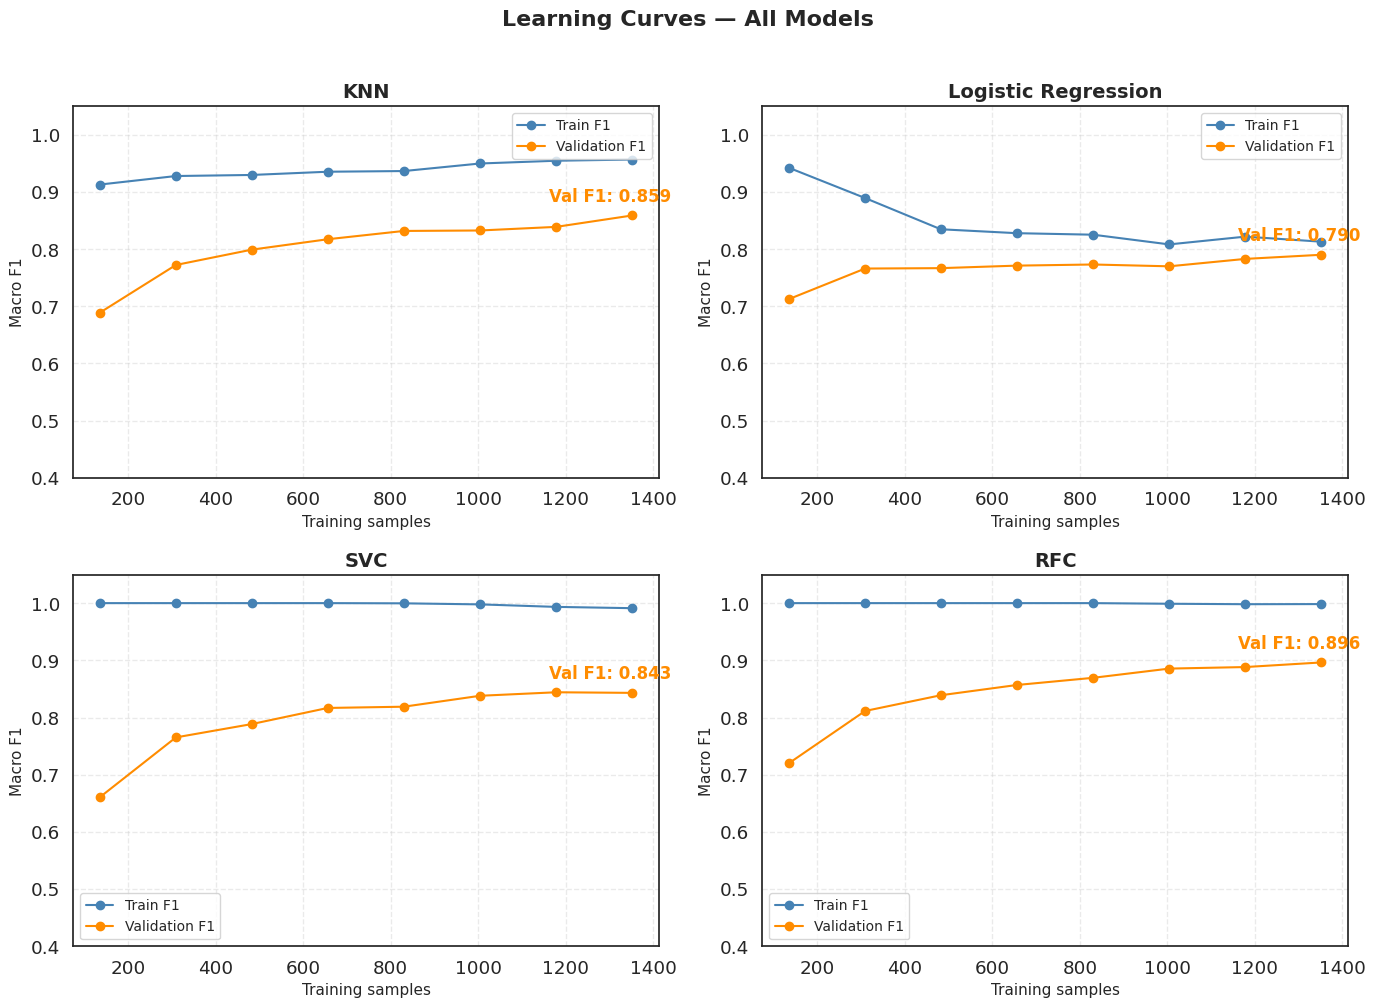

Saved: learning_curves.png


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold

def plot_learning_curves(grid_searches, X_train, y_train):
    """
    Plot learning curves for multiple models in a 2x2 grid.
    
    grid_searches: dict of {model_name: fitted GridSearchCV}
    """

    # ── CV strategy — same as training ───────────────────────────────────────
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # ── training set sizes to evaluate ───────────────────────────────────────
    train_sizes = np.linspace(0.1, 1.0, 8)

    # ── 2x2 subplot grid ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()   # flatten to index with 0,1,2,3

    for i, (model_name, gs) in enumerate(grid_searches.items()):

        # extract best estimator from each grid search
        best_estimator = gs.best_estimator_

        # compute learning curve
        train_sizes_abs, train_scores, val_scores = learning_curve(
            best_estimator,
            X_train, y_train,
            train_sizes=train_sizes,
            cv=cv,
            scoring="f1_macro",
            n_jobs=-1
        )

        # mean and std across CV folds
        train_mean = train_scores.mean(axis=1)
        train_std  = train_scores.std(axis=1)
        val_mean   = val_scores.mean(axis=1)
        val_std    = val_scores.std(axis=1)

        ax = axes[i]

        # ── train line ────────────────────────────────────────────────────────
        ax.plot(train_sizes_abs, train_mean,
                marker="o", label="Train F1", color="steelblue")
        # ax.fill_between(train_sizes_abs,
        #                 train_mean - train_std,
        #                 train_mean + train_std,
        #                 alpha=0.15, color="steelblue")

        # ── validation line ───────────────────────────────────────────────────
        ax.plot(train_sizes_abs, val_mean,
                marker="o", label="Validation F1", color="darkorange")
        # ax.fill_between(train_sizes_abs,
        #                 val_mean - val_std,
        #                 val_mean + val_std,
        #                 alpha=0.15, color="darkorange")

        # ── formatting ────────────────────────────────────────────────────────
        ax.set_title(model_name, fontsize=14, fontweight="bold")
        ax.set_xlabel("Training samples", fontsize=11)
        ax.set_ylabel("Macro F1", fontsize=11)
        ax.set_ylim(0.4, 1.05)
        ax.legend(fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.4)

        # annotate final validation score
        ax.annotate(
            f"Val F1: {val_mean[-1]:.3f}",
            xy=(train_sizes_abs[-1], val_mean[-1]),
            xytext=(-60, 10),
            textcoords="offset points",
            fontsize=12,
            fontweight="bold",
            color="darkorange"
        )

    plt.suptitle("Learning Curves — All Models", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: learning_curves.png")


# ── run ───────────────────────────────────────────────────────────────────────
grid_searches = {
    "KNN":                 grid_search_knn,
    "Logistic Regression": grid_search_logreg,
    "SVC":                 grid_search_svc,
    "RFC":                 grid_search_rfc
}

plot_learning_curves(grid_searches, X_train, y_train)